In [1]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
FILE_DIR = pathlib.Path('/Users/ashhadulislam/projects/general_data/CMI/ Detect Behavior with Sensor Data/cmi-detect-behavior-with-sensor-data/')  
SEED = 42


['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'adult_child', 'age', 'sex', 'handedness', 'height_cm', 'shoulder_to_wrist_cm', 'elbow_to_wrist_cm']
(574945, 23)


rot_w                   3692
rot_z                   3692
rot_y                   3692
rot_x                   3692
row_id                     0
shoulder_to_wrist_cm       0
height_cm                  0
handedness                 0
sex                        0
age                        0
adult_child                0
acc_z                      0
sequence_type              0
acc_y                      0
acc_x                      0
gesture                    0
phase                      0
behavior                   0
orientation                0
subject                    0
sequence_counter           0
sequence_id                0
elbow_to_wrist_cm          0
dtype: int64

(571253, 23)


row_id                  0
rot_w                   0
shoulder_to_wrist_cm    0
height_cm               0
handedness              0
sex                     0
age                     0
adult_child             0
rot_z                   0
rot_y                   0
rot_x                   0
acc_z                   0
sequence_type           0
acc_y                   0
acc_x                   0
gesture                 0
phase                   0
behavior                0
orientation             0
subject                 0
sequence_counter        0
sequence_id             0
elbow_to_wrist_cm       0
dtype: int64

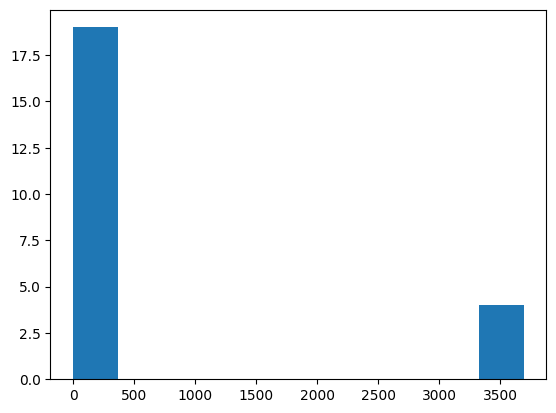

In [2]:
num_to_label = {
    0: "Above ear - pull hair",
    1: "Cheek - pinch skin",
    2: "Eyebrow - pull hair",
    3: "Eyelash - pull hair",
    4: "Forehead - pull hairline",
    5: "Forehead - scratch",
    6: "Neck - pinch skin",
    7: "Neck - scratch",
    8: "Drink from bottle/cup",
    9: "Feel around in tray and pull out an object",
    10: "Glasses on/off",
    11: "Pinch knee/leg skin",
    12: "Pull air toward your face",
    13: "Scratch knee/leg skin",
    14: "Text on phone",
    15: "Wave hello",
    16: "Write name in air",
    17: "Write name on leg"
}

label_to_num = {v: k for k, v in num_to_label.items()}

train_df=pd.read_csv(FILE_DIR/'train.csv')
train_demographics_df = pd.read_csv(FILE_DIR / 'train_demographics.csv')
train_df = pd.merge(train_df, train_demographics_df, how="left", on="subject")

select_cols=[]
for col in train_df.columns:
    if col.startswith('thm_') or col.startswith('tof_'):
        continue
    select_cols.append(col)
print(select_cols)

train_df=train_df[select_cols]

print(train_df.shape)
with pd.option_context('display.max_rows', None):
    display(train_df.isna().sum().sort_values(ascending=False))#

NA_vals=train_df.isna().sum().sort_values(ascending=False).values
plt.hist(NA_vals)    

train_df.dropna(inplace=True)

print(train_df.shape)
with pd.option_context('display.max_rows', None):
    display(train_df.isna().sum().sort_values(ascending=False))#

In [3]:
all_seq_lengths=[]
uniq_gestures=train_df.gesture.unique()
#print(uniq_gestures)
for chosen_gesture in uniq_gestures:
    label=label_to_num[chosen_gesture]
    df_gesture=train_df[train_df['gesture']==chosen_gesture]
    uniq_subjects=df_gesture.subject.unique()
    for chosen_subject in uniq_subjects:
        #print(uniq_subjects)                
        df_gesture_subject=df_gesture[df_gesture['subject']==chosen_subject]        
        uniq_sequences=df_gesture_subject.sequence_id.unique()
        for chosen_sequence in uniq_sequences:
            df_gesture_subject_sequence=df_gesture_subject[df_gesture_subject['sequence_id']==chosen_sequence]
            all_seq_lengths.append(df_gesture_subject_sequence.shape[0])

            # print(df_gesture.shape)        
            # print(chosen_subject)
            # print(df_gesture_subject.shape)
            # #print(uniq_sequences)            
            # print(chosen_sequence)
            

            



(array([7.079e+03, 8.350e+02, 1.300e+02, 3.400e+01, 1.000e+01, 8.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 3.000e+00]),
 array([ 29. ,  96.1, 163.2, 230.3, 297.4, 364.5, 431.6, 498.7, 565.8,
        632.9, 700. ]),
 <BarContainer object of 10 artists>)

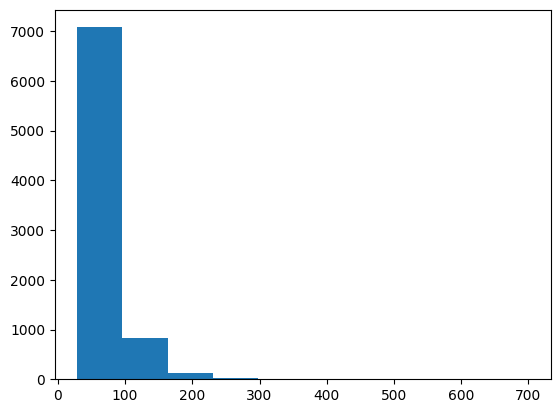

In [4]:
plt.hist(all_seq_lengths)

In [5]:
np.median(all_seq_lengths)

59.0

In [6]:
import pywt
import random


def convert_into_image(tseries):
    discrete_wavelets = pywt.wavelist(kind='discrete')
    print(discrete_wavelets)
    selected_wavelet_fams=random.sample(discrete_wavelets,15)

    values=[]
    for fam in selected_wavelet_fams:
        for i in range(tseries.shape[1]):
            (cA, cD) = pywt.dwt(tseries[:,i], 'db1')
            values.append(cA)
            values.append(cD)
    values=np.array(values)    
    print(values.shape)
    while values.shape[0]>values.shape[1]:
        new_values=[]
        for i in range(values.shape[0]-1):
            this=values[i,:]
            next=values[i+1,:]        
            new=(this+next)/2
            #print(new)
            new_values.append(new)
        new_values=np.array(new_values)
        #print(new_values.shape)
        values=new_values
    
    values=(values-np.min(values))/(np.max(values)-np.min(values))
    return values



In [7]:
min_seq_len=50
max_seq_len=90


X=[]
y=[]

series_cols=[
            'acc_x','acc_y','acc_z',
             #'rot_x','rot_y','rot_z',
             ]



uniq_gestures=train_df.gesture.unique()
#print(uniq_gestures)
for chosen_gesture in uniq_gestures:
    label=label_to_num[chosen_gesture]
    df_gesture=train_df[train_df['gesture']==chosen_gesture]
    uniq_subjects=df_gesture.subject.unique()
    for chosen_subject in uniq_subjects:
        #print(uniq_subjects)                
        df_gesture_subject=df_gesture[df_gesture['subject']==chosen_subject]        
        uniq_sequences=df_gesture_subject.sequence_id.unique()
        for chosen_sequence in uniq_sequences:
            df_gesture_subject_sequence=df_gesture_subject[df_gesture_subject['sequence_id']==chosen_sequence]
            seq_len=df_gesture_subject_sequence.shape[0]
            if seq_len>min_seq_len and seq_len<max_seq_len:
                tseries=df_gesture_subject_sequence[series_cols].values
                im_vals=convert_into_image(tseries)
                X.append(im_vals)
                y.append(label_to_num[chosen_gesture])

                



            # print(df_gesture.shape)        
            # print(chosen_subject)
            # print(df_gesture_subject.shape)
            # #print(uniq_sequences)            
            # print(chosen_sequence)
            

            



['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']
(90, 29)
['bior1.1', 'bior1.3', 'b

In [8]:

for i in range(len(X)):
    im_vals=X[i]
    im_vals=np.resize(im_vals,(30,30))
    X[i]=im_vals
    print(im_vals.shape)

(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(30, 30)
(

In [9]:
X=np.array(X)
y=np.array(y)

In [10]:
X.shape,y.shape,Counter(y)

((5048, 30, 30),
 (5048,),
 Counter({6: 427,
          4: 422,
          5: 419,
          14: 419,
          1: 413,
          0: 409,
          3: 402,
          2: 363,
          7: 334,
          12: 304,
          16: 286,
          15: 269,
          8: 108,
          17: 104,
          10: 101,
          11: 96,
          13: 87,
          9: 85}))

In [11]:
np.unique(y)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

class ImageDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  
        # (N, 1, 30, 30)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [13]:
import torch.nn as nn

class CNNAutoencoder(nn.Module):
    def __init__(self, bottleneck_dim):
        super().__init__()

        # -------- Encoder --------
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # (16, 15, 15)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # (32, 8, 8)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # (64, 4, 4)
            nn.ReLU()
        )

        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(64 * 4 * 4, bottleneck_dim)

        # -------- Decoder --------
        self.fc_dec = nn.Linear(bottleneck_dim, 64 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 8×8
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=0), # 15×15
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 31×31
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        z = self.fc_enc(x)           # bottleneck
        x = self.fc_dec(z)
        x = x.view(-1, 64, 4, 4)
        x = self.decoder(x)
        return x, z

In [14]:
def train_autoencoder(model, dataloader, epochs=30, lr=1e-3, device="mps"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loss_vals=[]
    for epoch in range(epochs):
        total_loss = 0
        for x in dataloader:
            x = x.to(device)

            optimizer.zero_grad()
            x_hat, _ = model(x)
            loss = criterion(x_hat, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        this_epoch_loss=total_loss/len(dataloader)        
        loss_vals.append(this_epoch_loss)
        if epoch%500==0:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {this_epoch_loss:.4f}")
    return loss_vals

In [15]:
# Example
bottleneck_dim = 8  # change this freely
batch_size = 32

dataset = ImageDataset(X)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

model = CNNAutoencoder(bottleneck_dim)
loss_vals=train_autoencoder(model, dataloader, epochs=501)

Epoch [1/501] Loss: 0.0974
Epoch [501/501] Loss: 0.0281


In [16]:
for nm,params in model.named_parameters():
    print(nm,params.shape)

encoder.0.weight torch.Size([16, 1, 3, 3])
encoder.0.bias torch.Size([16])
encoder.2.weight torch.Size([32, 16, 3, 3])
encoder.2.bias torch.Size([32])
encoder.4.weight torch.Size([64, 32, 3, 3])
encoder.4.bias torch.Size([64])
fc_enc.weight torch.Size([8, 1024])
fc_enc.bias torch.Size([8])
fc_dec.weight torch.Size([1024, 8])
fc_dec.bias torch.Size([1024])
decoder.0.weight torch.Size([64, 32, 3, 3])
decoder.0.bias torch.Size([32])
decoder.2.weight torch.Size([32, 16, 3, 3])
decoder.2.bias torch.Size([16])
decoder.4.weight torch.Size([16, 1, 3, 3])
decoder.4.bias torch.Size([1])


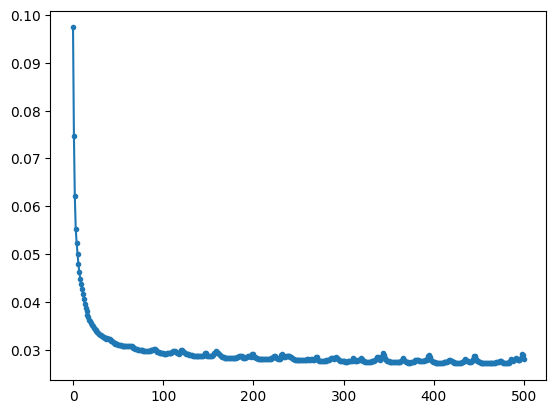

In [17]:
plt.plot(loss_vals,'.-')

In [18]:
import numpy as np
import torch

model.eval()

embeddings_list = []

with torch.no_grad():
    for x in DataLoader(dataset, batch_size=32, shuffle=False):
        x = x.to(next(model.parameters()).device)
        _, z = model(x)
        embeddings_list.append(z.cpu().numpy())

embeddings = np.vstack(embeddings_list)

print(embeddings.shape)
# (178, bottleneck_dim)

(5048, 8)


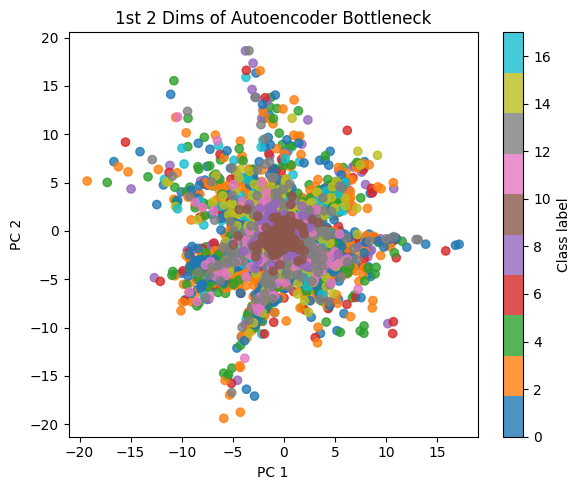

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    c=y,
    cmap="tab10",
    alpha=0.8
)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("1st 2 Dims of Autoencoder Bottleneck")
plt.colorbar(scatter, label="Class label")
plt.tight_layout()
plt.show()

In [20]:
# PCA
## 4 -> 3
from sklearn.decomposition import PCA
pca_n_components=4
pca = PCA(n_components=pca_n_components, random_state=42)
Z_pca = pca.fit_transform(embeddings)

print("Explained variance:", pca.explained_variance_ratio_.sum())

# 3-> 2
import umap

umap_n_components=2
umap_model = umap.UMAP(
    n_components=umap_n_components,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

Z_umap = umap_model.fit_transform(Z_pca)

Explained variance: 0.6899812


/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [21]:
Z_umap.shape

(5048, 2)

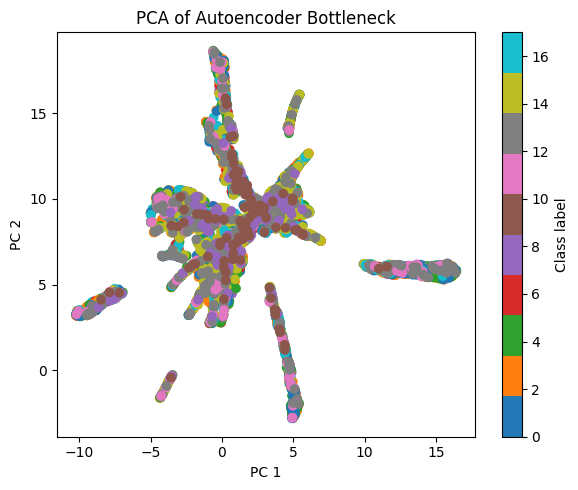

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    Z_umap[:, 0],
    Z_umap[:, 1],
    c=y,
    cmap="tab10",
    alpha=0.99
)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA of Autoencoder Bottleneck")
plt.colorbar(scatter, label="Class label")
plt.tight_layout()
plt.show()

In [23]:
Counter(y)

Counter({6: 427,
         4: 422,
         5: 419,
         14: 419,
         1: 413,
         0: 409,
         3: 402,
         2: 363,
         7: 334,
         12: 304,
         16: 286,
         15: 269,
         8: 108,
         17: 104,
         10: 101,
         11: 96,
         13: 87,
         9: 85})

In [24]:
y_bin=y.copy()

y_bin[y_bin<=7]=-1
y_bin[y_bin>7]=1
y_bin[y_bin==-1]=0



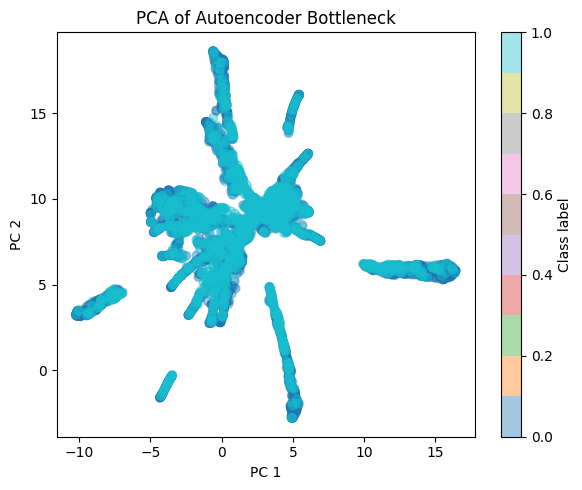

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    Z_umap[:, 0],
    Z_umap[:, 1],
    c=y_bin,
    cmap="tab10",
    alpha=0.4
)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA of Autoencoder Bottleneck")
plt.colorbar(scatter, label="Class label")
plt.tight_layout()
plt.show()